# MRQA Shared Task Dataset Exploration

Machine Reading for Question Answering shared task (~517K train + ~58K val + ~10K test).  
Pre-unified extractive QnA format covering multiple source datasets in a single schema.  
HuggingFace: `mrqa`

Train sub-datasets: SQuAD (87K), NewsQA (74K), TriviaQA-web (62K), SearchQA (117K), HotpotQA (73K), NaturalQuestionsShort (104K).  
Test sub-datasets (out-of-domain): BioASQ, DROP, DuoRC, RACE, RelationExtraction, TextbookQA.

Columns: `subset`, `context`, `context_tokens`, `qid`, `question`, `question_tokens`, `detected_answers` (char/token spans), `answers` (list[str])

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

MRQA_HF_ID = 'mrqa'
tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'DATA_PATH: {DATA_PATH}')
print(f'MRQA_HF_ID: {MRQA_HF_ID}')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

DATA_PATH: Q:\data
MRQA_HF_ID: mrqa
Tokenizer vocab size: 30522


## Load MRQA

In [4]:
# Load MRQA from HuggingFace
ds_mrqa = load_dataset(MRQA_HF_ID, cache_dir=str(DATA_PATH), trust_remote_code=True)
print(f'Splits: {list(ds_mrqa.keys())}')
for split_name, split_ds in ds_mrqa.items():
    print(f'  {split_name}: {len(split_ds)} examples')
print(f'\nFeatures: {list(ds_mrqa["train"].features.keys())}')

Splits: ['train', 'validation', 'test']
  train: 516819 examples
  validation: 58221 examples
  test: 9633 examples

Features: ['subset', 'context', 'context_tokens', 'qid', 'question', 'question_tokens', 'detected_answers', 'answers']


In [5]:
# Examine the structure of one example
ex = ds_mrqa['train'][0]
print('Keys:', list(ex.keys()))
print()
print(f'subset: {ex["subset"]}')
print(f'qid: {ex["qid"]}')
print(f'question: {ex["question"]}')
print(f'answers: {ex["answers"]}')
print(f'context: {ex["context"][:300]}...')
print()

# detected_answers has char_spans and token_spans
da = ex['detected_answers']
print(f'detected_answers ({len(da["text"])} answers):')
for j in range(len(da['text'])):
    txt = da['text'][j]
    char_spans = da['char_spans'][j]
    print(f'  [{j}] text="{txt}"')
    for cs in range(len(char_spans['start'])):
        s, e = char_spans['start'][cs], char_spans['end'][cs]
        print(f'       char_span [{s}:{e}]: "{ex["context"][s:e+1]}"')

Keys: ['subset', 'context', 'context_tokens', 'qid', 'question', 'question_tokens', 'detected_answers', 'answers']

subset: SQuAD
qid: 38cc2597b6624bd8af1e8ba7f693096f
question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
answers: ['Saint Bernadette Soubirous']
context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is ...

detected_answers (1 answers):
  [0] text="Saint Bernadette Soubirous"
       char_span [515:540]: "Saint Bernadette Soubirous"


## Dataset Statistics (per sub-dataset)

In [6]:
from collections import Counter

# Per-split, per-subset counts
for split_name in ds_mrqa:
    split_ds = ds_mrqa[split_name]
    subset_col = split_ds['subset']
    subsets = Counter(subset_col)
    print(f'{split_name} ({len(split_ds)} total):')
    for sub, cnt in subsets.most_common():
        print(f'  {sub}: {cnt}')
    print()

train (516819 total):
  SearchQA: 117384
  NaturalQuestionsShort: 104071
  SQuAD: 86588
  NewsQA: 74160
  HotpotQA: 72928
  TriviaQA-web: 61688

validation (58221 total):
  SearchQA: 16980
  NaturalQuestionsShort: 12836
  SQuAD: 10507
  TriviaQA-web: 7785
  HotpotQA: 5901
  NewsQA: 4212

test (9633 total):
  RelationExtraction: 2948
  BioASQ: 1504
  DROP: 1503
  TextbookQA: 1503
  DuoRC.ParaphraseRC: 1501
  RACE: 674



In [7]:
# Train split detailed stats
ds_train = ds_mrqa['train']
subset_col = ds_train['subset']
answers_col = ds_train['answers']
context_col = ds_train['context']

train_subsets = Counter(subset_col)
n_multi = sum(1 for a in answers_col if len(a) > 1)
n_empty = sum(1 for a in answers_col if len(a) == 0)
print(f'Total train: {len(ds_train)}')
print(f'Multi-answer questions: {n_multi} ({n_multi/len(ds_train):.1%})')
print(f'Empty-answer questions: {n_empty}')

# Unique contexts per subset
print('\nUnique contexts per subset (train):')
subset_ctx = {}
for i in range(len(subset_col)):
    sub = subset_col[i]
    if sub not in subset_ctx:
        subset_ctx[sub] = set()
    subset_ctx[sub].add(context_col[i][:200])
for sub in sorted(subset_ctx):
    print(f'  {sub}: {train_subsets[sub]} questions, ~{len(subset_ctx[sub])} unique contexts')

# Answer char length per subset
print('\nAnswer char lengths per subset (first answer):')
for sub_name in sorted(train_subsets):
    ans_lens = []
    for i in range(len(subset_col)):
        if subset_col[i] == sub_name and len(answers_col[i]) > 0:
            ans_lens.append(len(answers_col[i][0]))
    arr = np.array(ans_lens)
    print(f'  {sub_name}: mean={arr.mean():.1f}, median={np.median(arr):.0f}, max={arr.max()}')

Total train: 516819
Multi-answer questions: 29802 (5.8%)
Empty-answer questions: 0

Unique contexts per subset (train):
  HotpotQA: 72928 questions, ~51939 unique contexts
  NaturalQuestionsShort: 104071 questions, ~74865 unique contexts
  NewsQA: 74160 questions, ~10742 unique contexts
  SQuAD: 86588 questions, ~18877 unique contexts
  SearchQA: 117384 questions, ~112752 unique contexts
  TriviaQA-web: 61688 questions, ~56951 unique contexts

Answer char lengths per subset (first answer):
  HotpotQA: mean=14.3, median=13, max=529
  NaturalQuestionsShort: mean=23.7, median=14, max=1273
  NewsQA: mean=25.0, median=16, max=600
  SQuAD: mean=20.2, median=14, max=239
  SearchQA: mean=10.9, median=10, max=73
  TriviaQA-web: mean=9.9, median=9, max=134


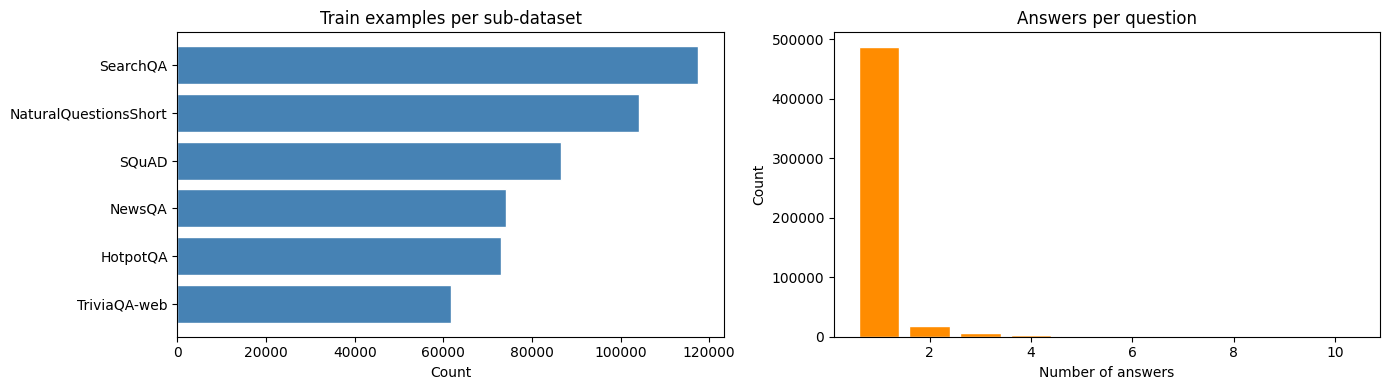

In [8]:
# Visualize subset distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Train subset sizes
sub_names = [s for s, _ in train_subsets.most_common()]
sub_counts = [c for _, c in train_subsets.most_common()]
axes[0].barh(sub_names[::-1], sub_counts[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Train examples per sub-dataset')
axes[0].set_xlabel('Count')

# Answer count distribution
ans_count_dist = Counter(len(a) for a in answers_col)
ac_keys = sorted(ans_count_dist.keys())[:10]
ac_vals = [ans_count_dist[k] for k in ac_keys]
axes[1].bar(ac_keys, ac_vals, color='darkorange', edgecolor='white')
axes[1].set_title('Answers per question')
axes[1].set_xlabel('Number of answers')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Inspect Examples

In [11]:
# Show examples from each sub-dataset
shown_subsets = set()
for i in range(len(ds_train)):
    sub = subset_col[i]
    if sub in shown_subsets:
        continue
    shown_subsets.add(sub)
    ex = ds_train[i]
    da = ex['detected_answers']

    print(f'=== {sub} (example {i}) ===')
    print(f'  Question: {ex["question"]}')
    print(f'  Answers: {ex["answers"]}')
    ctx = ex['context'][:300].replace('\n', ' ')
    print(f'  Context: {ctx}...')

    # Show first detected answer span in context
    if len(da['text']) > 0:
        txt = da['text'][0]
        cs = da['char_spans'][0]
        if len(cs['start']) > 0:
            s, e = cs['start'][0], cs['end'][0]
            ctx_off = 40
            beg = max(s - ctx_off, 0)
            ctx_around = ex['context'][beg:e + 1 + ctx_off]
            ctx_around = ctx_around.replace('\n', ' ')
            print(f'  Span [{s}:{e}]: "{txt}"')
            print(f'  In context: "...{ctx_around}..."')
    print()

    if len(shown_subsets) >= len(train_subsets):
        break

=== SQuAD (example 0) ===
  Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
  Answers: ['Saint Bernadette Soubirous']
  Context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is ...
  Span [515:540]: "Saint Bernadette Soubirous"
  In context: "...e the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (..."

=== NewsQA (example 86588) ===
  Question: What was the amount of children murdered?
  Answers: ['19']
  Context: NEW DELHI, India (CNN) -- A high court in northern India on Friday acquitted a wealthy businessman facing the death sentence for the killing of a teen in a case dubbed "the house of horrors."    Moninder Singh Pandher was sentenced to death b

## Filter & Deduplicate Against Other Loaded Datasets

In [13]:
# MRQA train contains SQuAD, NewsQA, TriviaQA, SearchQA, HotpotQA, NQ.
# Since we already load SQuAD v2, NewsQA, TriviaQA, NQ as standalone datasets,
# we can either:
#   (a) Use MRQA as a unified source and skip the standalone ones, or
#   (b) Use standalone datasets + MRQA subsets not separately loaded (SearchQA, HotpotQA)
#
# Approach (b) is better: standalone datasets have richer metadata.
# Here we filter MRQA to only keep SearchQA and HotpotQA (not available standalone in our pipeline).

MRQA_KEEP_SUBSETS = {'SearchQA', 'HotpotQA'}

question_col = ds_train['question']
keep_mask = [subset_col[i] in MRQA_KEEP_SUBSETS for i in range(len(subset_col))]
n_keep = sum(keep_mask)
print(f'Keeping MRQA subsets: {MRQA_KEEP_SUBSETS}')
print(f'Rows to keep: {n_keep}/{len(ds_train)} ({n_keep/len(ds_train):.1%})')
for sub in sorted(MRQA_KEEP_SUBSETS):
    cnt = train_subsets[sub]
    print(f'  {sub}: {cnt}')

Keeping MRQA subsets: {'HotpotQA', 'SearchQA'}
Rows to keep: 190312/516819 (36.8%)
  HotpotQA: 72928
  SearchQA: 117384


## Context / Answer Length Distributions

In [14]:
# Tokenize contexts, questions, answers for the kept subsets and measure lengths
mrqa_ctx_lens = []
mrqa_q_lens = []
mrqa_ans_lens = []

for i in range(len(ds_train)):
    if not keep_mask[i]:
        continue
    ctx_toks = tkz(context_col[i], add_special_tokens=False).input_ids
    q_toks = tkz(question_col[i], add_special_tokens=False).input_ids
    ans = answers_col[i]
    ans_toks = tkz(ans[0], add_special_tokens=False).input_ids if len(ans) > 0 else []

    mrqa_ctx_lens.append(len(ctx_toks))
    mrqa_q_lens.append(len(q_toks))
    mrqa_ans_lens.append(len(ans_toks))

mrqa_ctx_lens = np.array(mrqa_ctx_lens)
mrqa_q_lens = np.array(mrqa_q_lens)
mrqa_ans_lens = np.array(mrqa_ans_lens)

print(f'Processed {len(mrqa_ctx_lens)} examples (SearchQA + HotpotQA)')
print('\nContext token lengths:')
print(f'  mean={mrqa_ctx_lens.mean():.1f}, median={np.median(mrqa_ctx_lens):.1f}, '
      f'min={mrqa_ctx_lens.min()}, max={mrqa_ctx_lens.max()}, std={mrqa_ctx_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={mrqa_q_lens.mean():.1f}, median={np.median(mrqa_q_lens):.1f}, '
      f'min={mrqa_q_lens.min()}, max={mrqa_q_lens.max()}, std={mrqa_q_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={mrqa_ans_lens.mean():.1f}, median={np.median(mrqa_ans_lens):.1f}, '
      f'min={mrqa_ans_lens.min()}, max={mrqa_ans_lens.max()}, std={mrqa_ans_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (527 > 512). Running this sequence through the model will result in indexing errors


Processed 190312 examples (SearchQA + HotpotQA)

Context token lengths:
  mean=703.0, median=982.0, min=42, max=2025, std=399.7
Question token lengths:
  mean=20.6, median=19.0, min=1, max=141, std=9.8
Answer token lengths:
  mean=2.8, median=2.0, min=1, max=118, std=2.0


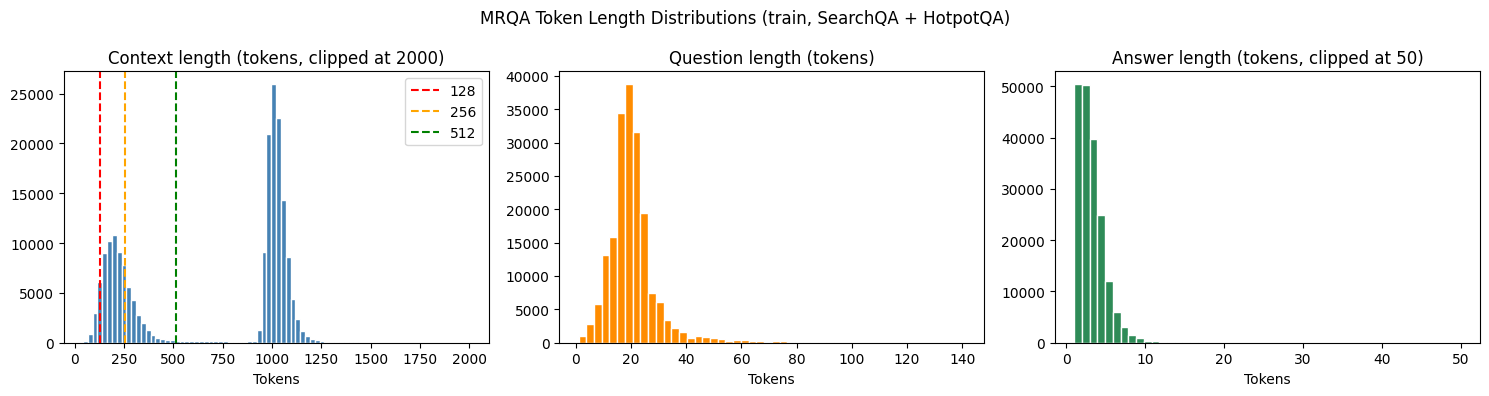

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ctx_clip = np.clip(mrqa_ctx_lens, 0, 2000)
axes[0].hist(ctx_clip, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens, clipped at 2000)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(mrqa_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(np.clip(mrqa_ans_lens, 0, 50), bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens, clipped at 50)')
axes[2].set_xlabel('Tokens')

plt.suptitle('MRQA Token Length Distributions (train, SearchQA + HotpotQA)')
plt.tight_layout()
plt.show()

In [16]:
# Chunk analysis
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2
    n_chunks = np.ceil(mrqa_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(mrqa_ctx_lens)} ({multi/len(mrqa_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 183843/190312 (96.6%), max chunks: 17, mean chunks: 6.07
inp_len=256: need >1 chunk: 135456/190312 (71.2%), max chunks: 8, mean chunks: 3.23
inp_len=384: need >1 chunk: 117344/190312 (61.7%), max chunks: 6, mean chunks: 2.23
inp_len=512: need >1 chunk: 114983/190312 (60.4%), max chunks: 4, mean chunks: 1.90


## Convert to Unified QnA Format

In [ ]:
# Convert MRQA to unified QnA format: (context, question, answer, source)
# Use train + validation splits; only keep SearchQA and HotpotQA subsets
rows_unified = []
for split_name in ['train', 'validation']:
    split_ds = ds_mrqa[split_name]
    sub_col = split_ds['subset']
    ctx_col = split_ds['context']
    q_col = split_ds['question']
    ans_col = split_ds['answers']
    for i in range(len(split_ds)):
        if sub_col[i] not in MRQA_KEEP_SUBSETS:
            continue
        answers = ans_col[i]
        context = ctx_col[i]
        question = q_col[i]
        if not answers or not context.strip() or not question.strip():
            continue
        rows_unified.append({
            'context': context,
            'question': question,
            'answer': answers[0],
            'source': f'mrqa_{sub_col[i].lower()}',
        })

df_unified_mrqa = pd.DataFrame(rows_unified)
print(f'Unified MRQA rows (train+val, SearchQA + HotpotQA): {len(df_unified_mrqa)}')
print(df_unified_mrqa['source'].value_counts())
df_unified_mrqa.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'mrqa_unified.parquet'
df_unified_mrqa.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_mrqa)} rows)')